# Práctica final Deep Learning para series temporales

En este proyecto, abordaremos un problema de clasificación de series temporales aplicado al ámbito médico, en nuestro caso centraremos el análisis en señales de electrocardiograma (ECG). El objetivo es desarrollar un modelo de Deep Learning que pueda clasificar latidos cardíacos en distintas categorías, diferenciando un latido normal de distintos tipos de arritmias.

Trabajaremos a partir del [ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat/data) disponible en Kaggle, constituido a partir de la MIT-BIH Arrhythmia Database, referencia en la investigación de proceso de señales biomédicas.

El problema está planteado como una tarea de clasificación multiclase, con 5 categorías de latidos cardíacos individuales. Para abordarlo, primero llevaremos un análisis exploratorio de los datos, para entender bien la estructura del dataset y sus características. Posteriormente, diseñaremos distintos modelos de Deep Learning, evaluaremos su rendimiento, y compararemos los resultados obtenidos con el fin de seleccionar el mejor modelo para resolver esta clasificación.

A continuación entonces, procedemos a instalar las dependencias y librerías necesarias para el desarrollo del proyecto.

In [ ]:
!pip install -r requirements.txt

In [ ]:
!python scripts/download_dataset.py

In [2]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.3 MB/s eta 0:00:00


In [3]:
# IMPORTS
# librerías estándar
import os
import shutil
import random

# librerías de terceros
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader


# PyTorch Lightning
import pytorch_lightning as pl

from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Torchmetrics
from torchmetrics import F1Score

from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Se fija una semilla aleatoria para garantizar la reproducibilidad básica de los experimentos.

In [5]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

os.environ["PYTHONHASHSEED"] = str(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Definimos una estructura de directorios para organizar los resultados del experimento, incluyendo checkpoints, figuras generadas durante el análisis y resultados finales:

In [7]:
BASE_PATH = "."

CHECKPOINT_PATH = os.path.join(BASE_PATH, "checkpoints")
FIGURES_PATH = os.path.join(BASE_PATH, "figures")
RESULTS_PATH = os.path.join(BASE_PATH, "results")
MODELS_PATH = os.path.join(BASE_PATH, "models")

for path in [CHECKPOINT_PATH, MODELS_PATH, FIGURES_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

## Análisis exploratorio de los datos

Para comprendar la estructura y características del dataset, estudiaremos en esta sección la organización del mismo, para identificar posibles particularidades del problema, como desbalance de clases. Es un paso necesario para luego poder tomar decisiones relacionadas con el preprocesamiento y diseño del modelo.



### Estructura del dataset

Primeramente, cargamos los conjuntos de entrenamiento y test a partir de los archivos proporcionados.

In [9]:
train_df = pd.read_csv(
    f"{BASE_PATH}/data/mitbih_train.csv",
    header=None
)

test_df = pd.read_csv(
    f"{BASE_PATH}/data/mitbih_test.csv",
    header=None
)

print(f"Training Data Shape: {train_df.shape}")
print(f"Testing Data Shape: {test_df.shape}")

Training Data Shape: (87554, 188)
Testing Data Shape: (21892, 188)


EL conjunto de entrenamiento contiene **87554** muestras y el de test **21892**. Cada muestra está representada por 188 columnas. Cada registro se compone de:
- 187 valores numéricos, que representan la señal ECG
- 1 valor que corresponde a la etiqueta de clase

Según la documentación del dataset, el último elemento de cada fila corresponde a la **etiqueta de clase** (columna 187), mientras que los 187 valores previos corresponden a la serie temporal del latido cardíaco.

In [10]:
train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
count,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,...,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000,87554.000000
mean,0.890360,0.758160,0.423972,0.219104,0.201127,0.210399,0.205808,0.201773,0.198691,0.196757,...,0.005025,0.004628,0.004291,0.003945,0.003681,0.003471,0.003221,0.002945,0.002807,0.473376
std,0.240909,0.221813,0.227305,0.206878,0.177058,0.171909,0.178481,0.177240,0.171778,0.168357,...,0.044154,0.042089,0.040525,0.038651,0.037193,0.036255,0.034789,0.032865,0.031924,1.143184
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.921922,0.682486,0.250969,0.048458,0.082329,0.088416,0.073333,0.066116,0.065000,0.068639,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991342,0.826013,0.429472,0.166000,0.147878,0.158798,0.145324,0.144424,0.150000,0.148734,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.910506,0.578767,0.341727,0.258993,0.287628,0.298237,0.295391,0.290832,0.283636,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


Comprobamos que tanto el dataset de entrenamiento como de test no contienen valores nulos:

In [11]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


In [12]:
print(train_df.isna().any().any())
print(test_df.isna().any().any())

False
False


También comprobamos rápidamente que todas las variables son numéricas, lo que permite un uso directo en modelos:

In [13]:
train_df.dtypes

,0
0,float64
1,float64
2,float64
3,float64
4,float64
...,...
183,float64
184,float64
185,float64
186,float64


A continuación, separamos las variables de entrada (X) y las etiquetas (y):

- Entrenamiento: `X_train` y `y_train`

- Test: `X_test` y `y_test`

Esta separación es necesaria para el entrenamiento supervisado de modelos de aprendizaje automático, ya que el modelo utilizará las señales ECG como entrada para aprender a predecir correctamente la categoría de cada muestra.

In [14]:
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (87554, 187)
y_train: (87554,)


Procedemos a analizar el rango de valores de las señales, observando los valores mínimos y máximos del conjunto de train:

In [15]:
print("Min:", X_train.min().min())
print("Max:", X_train.max().max())

Min: 0.0
Max: 1.0


Los resultados muestras que los datos se encuentran en un intervalo [0, 1], lo que significa que las señales están normalizadas, lo que nos permitirá obtener un entrenamiento más estable y facilita también la convergencia de los algoritmos de optimización. Por lo tanto, **no será necesario aplicar algún proceso adicional de normalización antes del entrenamiento**.

### Distribución de clases

Las etiquetas del dataset corresponden a una agrupación de distintos tipos de latidos cardíacos, basada en la anotación estándar de la base de datos MIT-BIH Arrhythmia. Contiene originalmente múltiples tipos de latidos anotados mediante códigos alfabeticos, divididos en 5 categorías principales, como vemos en la documentación de Kaggle: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]

Adentrándonos en la [documentación original de MIT-BIH](https://archive.physionet.org/physiobank/database/html/mitdbdir/intro.htm#annotations), estas anotaciones corresponden a los siguientes tipos de latidos:

- 0 = N = Normal beat (latido normal del corazón, con forma de onda ECG sin anomalías)
- 1 = S = Supraventricular premature beat (latido prematuro que se origina en la parte superior del corazón, las aurículas, no siempre es grave)
- 2 = V = Premature ventricular contraction (latido prematuro que se origina en los ventículos y se puede asociar a problemas cardíacos más serios)
- 3 = F = Fusion of ventricular and normal beat (latido híbrido que mezcla características de un latido normal y un latido ventricular, producidos casi simultáneamente)
- 4 = Q = Unclassifiable beat (no se pueden clasificar en las categorías anteriores, por ruido, anomalías menos comunes, etc.)



Esta agrupación sigue el estándar AAMI (Association for the Advancement of Medical Instrumentation), utilizado en tareas de clasificación de arritmias. Las clases han sido codificadas numéricamente de 0 a 4 para su uso en modelos de aprendizaje automático.

/tmp/ipykernel_560/1844573421.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, ax=ax, palette="viridis")


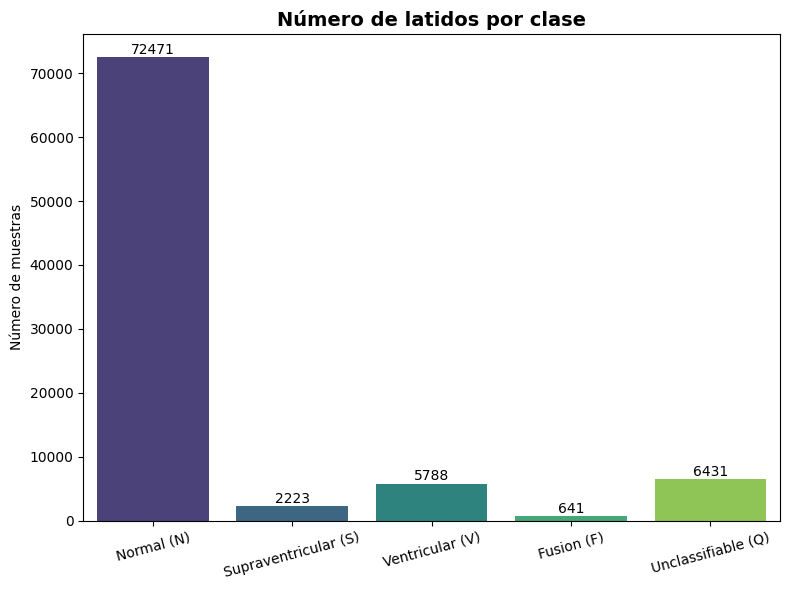

In [16]:
class_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unclassifiable (Q)']

class_counts = y_train.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 6))

# histograma
sns.barplot(x=class_names, y=class_counts.values, ax=ax, palette="viridis")

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, str(v), ha='center', fontsize=10)

ax.set_title('Número de latidos por clase', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de muestras')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


In [17]:
class_distribution = pd.DataFrame({
    'Clase': class_names,
    'Recuento': class_counts.values,
    'Porcentaje': ((class_counts.values / len(train_df)) * 100).round(2)
})

class_distribution

,Clase,Recuento,Porcentaje
0,Normal (N),72471,82.77
1,Supraventricular (S),2223,2.54
2,Ventricular (V),5788,6.61
3,Fusion (F),641,0.73
4,Unclassifiable (Q),6431,7.35


El análisis de la distribución de clases muestra un **desbalance severo**. La clase correspondiente a los latidos normales (N) representa la gran mayoría de las muestras (más del 82%), en comparación con las muestras de arritmia, y la clase 3 (F), es muy minoritaria.

Este desbalance puede afectar negativamente el entrenamiento del modelo de clasificación, ya que podría favorecer la clase mayoritaria.

Teniendo este aspecto en cuenta, será necesario utilizar métricas de evaluación representativas, en especial para evaluar el rendimiento sobre las clases más minoritarias. Se tendrán en cuenta en el preprocesado estrategias para paliar este desbalance, como el uso de `class weights` o técnica de balanceo aplicadas solo sobre el conjunto de entrenamiento.

### Visualización de señales ECG

La visualización de señales permite observar las distintas morfologías de las clases presentes en el dataset. Veamos un ejemplo de cada clase:

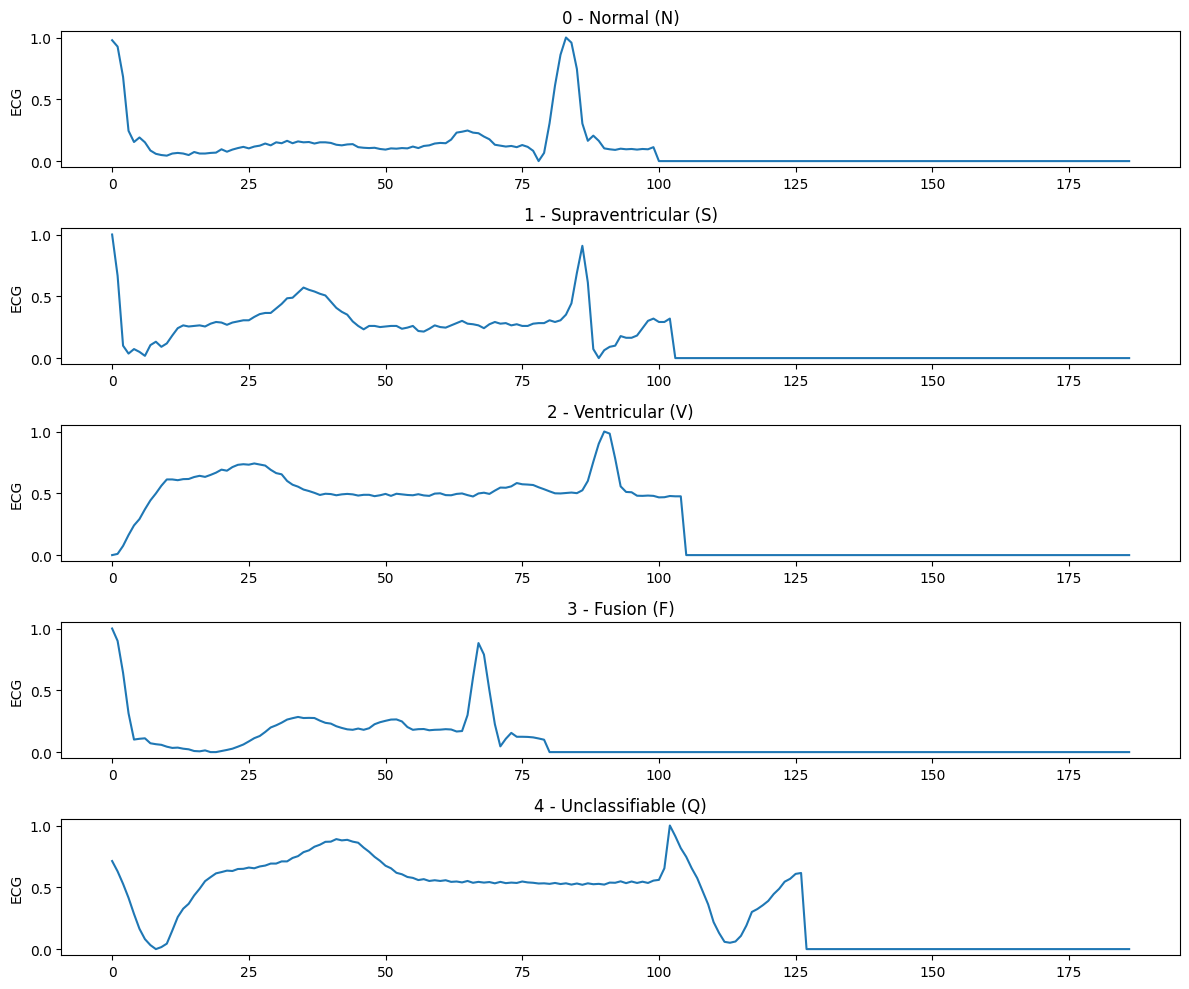

In [18]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10))

for c in range(5):
    idx = np.where(y_train == c)[0][0]
    axes[c].plot(X_train.iloc[idx])
    axes[c].set_title(f"{c} - {class_names[c]}")
    axes[c].set_ylabel("ECG")

plt.tight_layout()
plt.show()

Estas visualizaciones muestran un ejemplo de señal ECG por cada clase presente en el dataset. Representan cada una un latido cardíaco representado como una serie temporal, de longitud fija.

Se observan **variedades de forma entre las categorías**, las muestras de arritmia presentan picos y variaciones de amplitudes, en comparación con la muestra de latido normal. Esto sugiere que estas muestran presentan patrones temporales característicos, y el hecho de que tengan la misma longitud permite una utilización directa como entrada de modelos de Deep Learning.

Más allá de la diferencia morfológica, también vemos **variaciones en la posición temporal de los picos de la señal** entre las distintas clases. El eje horizontal representa las muestras temporales de la señal. Siguiendo la documentación, sabemos que este dataset utiliza una frecuencia de 125 Hz, cada punto representa entonces uno 0.008 segundos. Como cada señal contiene 187 muestras, cada latido corresponde a 1.5 segundos de actividad cardíaca. Entonces, visto que el pico aparece en puntos distintos del eje X, podemos entender que el momento clave del latido ocurre en distintas franjas temporales dentro de la ventana analizada.

A continuación, veamos varios ejemplos de cada clase, para intentar determinar algún patrón inicial:

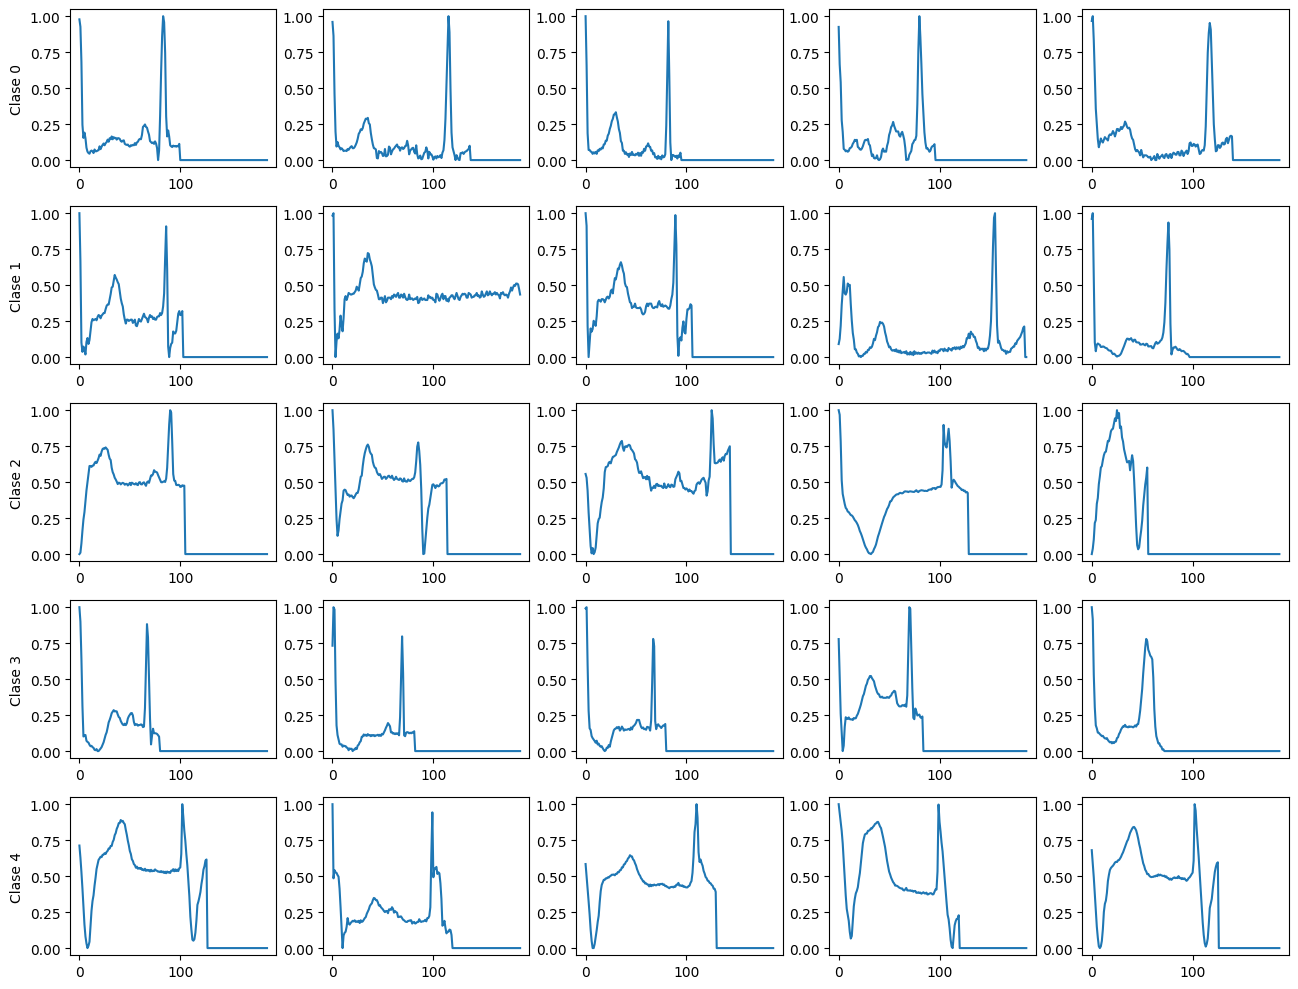

In [19]:
fig, axes = plt.subplots(5, 5, figsize=(13, 10))

for c in range(5):

    idxs = np.where(y_train == c)[0][:5]

    for j, idx in enumerate(idxs):

        axes[c, j].plot(X_train.iloc[idx].values)

        if j == 0:
            axes[c, j].set_ylabel(f"Clase {c}")

plt.tight_layout()
plt.show()

Con la visualización múltiple, podemos observar una variabilidad intra-clase importante. Las muestras no presentan una forma idéntica pero sí unas características globales observables. Se pueden ocasionar estas diferencias por la variedad fisiológica entre los pacientes clínicos o bien por el ruido. Para consolidar el análisis, veamos finalmente la media y desviación estándar por clase:

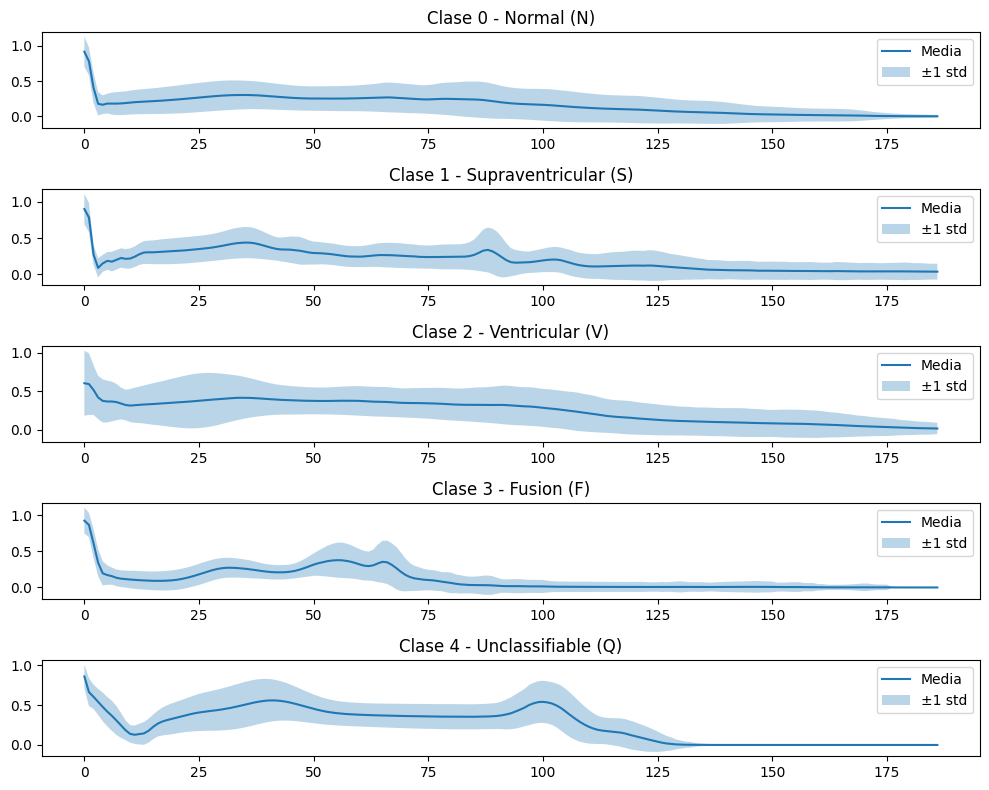

In [20]:
fig, axes = plt.subplots(5, 1, figsize=(10, 8))

for c in range(5):

    idxs = np.where(y_train == c)[0]

    signals = X_train.iloc[idxs].values

    mean_signal = signals.mean(axis=0)
    std_signal = signals.std(axis=0)

    timesteps = np.arange(signals.shape[1])

    axes[c].plot(
        timesteps,
        mean_signal,
        label="Media"
    )

    axes[c].fill_between(
        timesteps,
        mean_signal - std_signal,
        mean_signal + std_signal,
        alpha=0.3,
        label="±1 std"
    )

    axes[c].set_title(f"Clase {c} - {class_names[c]}")
    axes[c].legend()

plt.tight_layout()
plt.show()

Se observa que algunas regiones muestras más dispersión, en especial alrededor de los picos principales de las señales; el resto de regiones presentan un comportamiento bastante estable y consistente. Este análisis dirige la atención a los picos, que parecen ser los que mayor información discriminativa contengan, sugiriendo el uso de arquitectura convolucional 1D, más herméticas a pequeñas variaciones temporales pero capaces de detectar características morfológicas.

## Preprocesamiento


### División de los datos

Aunque el dataset MIT-BIH ya está dividido entre train y test, haremos a continuación una división adicional del conjunto de entrenamiento para obtener un conjunto intermedio de validación. Se utilizará durante el entrenamiento para monotorizar el rendimiento del modelo y mantener el conjunto de test aislado completamente, hasta la evaluación final.

En este particionado, aplicamos `stratify=y_train` para mantener la distribución original de clases, lo que es especialmente relevante debido al desbalanceo observado en el análisis exploratorio.

Se utilizarán un **20%** de los datos para validación, siguiendo una partición estándar en problemas de clasificación supervisada.

In [21]:
X = train_df.iloc[:, :-1].values
y = train_df.iloc[:, -1].astype(int).values

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2, # split 80%-20%
    random_state=seed, # 42
    stratify=y
)

A continuación verificamos que la estructura del dataset es coherente:

In [23]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (70043, 187) (70043,)
Validation: (17511, 187) (17511,)
Test: (21892, 187) (21892,)


Observamos que las señales presentan una longitud fija de 187 muestras temporales, lo que indica que no es necesario añadir padding o recortar. Confirmamos también que existe una correspondencia entre las señalas X y su etiqueta y, garantizando la integridad del dataset después de particionado.

Por otra parte, comprobamos que la distribución de clases se mantiene constante entre entrenamiento y validación, al aplicar stratify:

In [24]:
def print_distribution(y, name):
    classes, counts = np.unique(y, return_counts=True)
    dist = counts / len(y)
    print(f"\n{name}")
    for c, d in zip(classes, dist):
        print(f"Clase {c}: {d:.4f}")

In [25]:
print_distribution(y_train, "Train")
print_distribution(y_val, "Validation")


Train
Clase 0: 0.8277
Clase 1: 0.0254
Clase 2: 0.0661
Clase 3: 0.0073
Clase 4: 0.0735

Validation
Clase 0: 0.8277
Clase 1: 0.0254
Clase 2: 0.0661
Clase 3: 0.0073
Clase 4: 0.0734


### Class weights

Visto el desbalanceo de clases detectado en el análisis exploratorio, se calculan pesos inversamente proporcionales a la frecuencia de cada clase para compensar el sesgo hacia la clase mayoritaria durante el entrenamiento.

Se usa la función `compute_class_weight` de Skikit-learn. Estos pesos permiten compensar la influencia de las clases mayoritarias durante el entrenamiento, evitando el sesgo del modelo hacia ellas.

In [26]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

### Reshape de las señales de entrada

Para adaptar las señales al formato requerido por redes neuronales convolucionales 1D, que esperan una estructura con forma (samples, timesteps, channels), añadimos una dimensión adicional que representa el canal de la señal. Obtenemos entonces la forma final (muestras, 187, 1).


In [27]:
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

In [28]:
X_train = X_train[:, :, np.newaxis]
X_val = X_val[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]

print("Nuevo shape train:", X_train.shape)
print("Nuevo shape val:", X_val.shape)
print("Nuevo shape test:", X_test.shape)

Nuevo shape train: (70043, 187, 1)
Nuevo shape val: (17511, 187, 1)
Nuevo shape test: (21892, 187, 1)


### Conversión a torch.tensor

Las etiquetas se convierten a tipo torch.long, ya que la función de pérdida estándar utilizada en problemas de clasificación multiclase (CrossEntropyLoss) requiere índices de clase enteros como targets.

In [29]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

### DataModule

Para organizar el flujo de datos, usamos un `DataModule` de PyTorch Lightning, que centraliza la gestión de los conjuntos de entrenamiento, validación y test, así como la creación de los dataloaders.

Se utiliza `TensorDataset` de PyTorch como implementación directa del dataset, ya que los datos ya se encuentran completamente preprocesados y estructurados. Esta clase permite asociar directamente cada señal EGC con su etiqueta. Esto nos permite evitar la necesidad de definir un dataset personalizado, simplificando el pipeline sin pérdida de funcionalidad.

Se fija el **batch_size=64** para mantener un buen equilibrio entre estabilidad del gradiente y eficiencia computacional. Aplicamos **shuffle=True** en el conjunto de entrenamiento, mezclando aleatoriamente las muestras en cada época, para mejorar la capacidad de generalización del modelo, mientras que los conjuntos de validación y test se mantienen intactos.

In [30]:
class ECGDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_dataset = TensorDataset(self.X_train, self.y_train)
        self.val_dataset = TensorDataset(self.X_val, self.y_val)
        self.test_dataset = TensorDataset(self.X_test, self.y_test)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

## Baseline

Visto que las señales EGC presentan patrones locales característicos, se propone como baseline una **red convolucional unidimensional (CNN-1D)**.

Efectivamente, las CNN-1D son especialmente adecuadas para este tipo de señales, ya que permiten detectar patrones morfológicos relevantes a través de filtros convolucionales, aplicados sobre la dimensión temporal. También son robustos a pequeñas variaciones temporales, que observamos durante el análisis exploratorio.

La arquitectura combina:
- capas convolucionales para extraer las características de las señales
- operaciones de pooling para reducir la dimensionalidad
- capas densas finales para la clasificación multiclase de los latidos

### Arquitectura CNN-1D

La arquitectura propuesta se compone de dos bloques convolucionales seguidos de operaciones de max pooling, que permiten reducir la dimensionalidad de la señal y mejorar la robustez del modelo frente a pequeñas variaciones temporales. Luego, las características extraídas se transforman mediante capas densas para hacer la clasificación final en las 5 categorías presentes en el dataset.

Se han definido los siguientes valores iniciales:
- `kernel_size` ➡️ **5** (timesteps consecutivos), suficientes para capturar patrones locales de corta duración en la señal ECG sin perder resolución temporal.
- `out_channels` ➡️ **32** y **64**. Se aumenta progresivamente el número de filtros de 32 a 64 canales, para que la red aprenda representaciones cada vez más complejas, a medida que aumenta la profundidad de la arquitectura.
- `max pooling` ➡️ **kernel_size=2**, reduciendo la dimensionalidad y el coste computacional, además de mejorar la robustez frente a pequeñas variaciones temporales.
- `dropout` ➡️ **0.3**, con un buen equilibrio entre regularización sin perder demasiada información.
- `learning rate` ➡️ **1e-3**, valor estándar en arquitecturas convolucionales, con buena estabilidad y capacidad de convergencia.
- `batch size` ➡️ **64**, también estándar, con un equilibrio adecuado entre eficiencia computacional y estabilidad del gradiente.
- `loss` ➡️ **Cross Entropy**: función de pérdida estándar para problemas de clasificación multiclase.

Los hiperparámetros relevantes de la arquitectura, como la tasa de aprendizaje o el dropout, se parametrizan dentro del constructor del modelo para facilitar la experimentación sistemática y la comparación entre configuraciones.

Creamos una primera clase de base, de la cual heredará tanto el baseline como los próximos experimentos, para mantener el código limpio y reproducible.

In [31]:
class BaseECGCNN(pl.LightningModule):
    def __init__(self, num_classes=5, learning_rate=1e-3, dropout=0.3, class_weights=None):
        super().__init__()
        self.save_hyperparameters() # guardar hiperparámetros automáticamente en checkpoints

        self.learning_rate = learning_rate

        # loss con class weights: penaliza más errores en clases minoritarias y menos en clase dominante
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)

        # guardamos predicciones en test
        self.test_preds = []
        self.test_targets = []

        # métricas
        self.train_acc = MulticlassAccuracy(num_classes=num_classes)
        self.val_acc = MulticlassAccuracy(num_classes=num_classes)
        self.test_acc = MulticlassAccuracy(num_classes=num_classes)

        self.train_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.val_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
        self.test_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

    # función compartida para las métricas
    def compute_metrics(self, preds, y, stage="train"):
        if stage == "train":
            acc = self.train_acc(preds, y)
            f1 = self.train_f1(preds, y)

        elif stage == "val":
            acc = self.val_acc(preds, y)
            f1 = self.val_f1(preds, y)

        elif stage == "test":
            acc = self.test_acc(preds, y)
            f1 = self.test_f1(preds, y)

        self.log(
            f"{stage}_acc",
            acc,
            prog_bar=True,
            on_epoch=True
        )

        self.log(
            f"{stage}_f1",
            f1,
            prog_bar=True,
            on_epoch=True
        )

    def shared_steps(self, batch, stage="train"):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)

        self.compute_metrics(preds, y, stage=stage)

        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True)

        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, _, _ = self.shared_steps(batch, stage="train")

        return loss

    def validation_step(self, batch, batch_idx):
        loss, _, _ = self.shared_steps(batch, stage="val")

    def test_step(self, batch, batch_idx):
        loss, preds, y = self.shared_steps(batch, stage="test")

        self.test_preds.append(preds.detach().cpu())
        self.test_targets.append(y.detach().cpu())

        return loss

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_targets = []

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.learning_rate
        )

        return optimizer

In [32]:
class ECGCNN(BaseECGCNN):

    def __init__(self, num_classes=5, learning_rate=1e-3, dropout=0.3, class_weights=None):
        super().__init__(
            num_classes=num_classes,
            learning_rate=learning_rate,
            class_weights=class_weights
        )

        # bloque convolucional
        # capa 1: aprende patrones simples
        self.conv1 = nn.Conv1d(
            in_channels=1, # un solo canal EGC
            out_channels=32, # la red aprende con 32 filtros distintos
            kernel_size=5, # pequeño patrón local temporal (5 timesteps vecinos)
            padding=2 # se mantiene la longitud temporal
        )

        # capa 2: aprende representaciones más abstractas
        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            padding=2
        )

        # pooling
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # clasificador
        self.fc1 = nn.Linear(64, 128)

        self.dropout = nn.Dropout(dropout)

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Conv1D espera: (batch, channels, timesteps)
        x = x.permute(0, 2, 1) # permute para cambiar la forma a (batch, channels, timesteps)

        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))

        x = self.global_pool(x)
        x = x.squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### Callbacks

Los callbacks permiten detener el entrenamiento cuando no mejora (EarlyStopping) y guardar automáticamente el mejor modelo (Checkpoint). Se determinan los siguientes valores:

<u>**Early Stopping**</u>

- `patience` ➡️ **5**, permitiendo pequeñas oscilaciones sin detener el entrenamiento demasiado pronto.
- `monitor` ➡️ **F1 score en validación**, ya que nos enfrentamos a unas clases desbalanceadas, nos proporciona una evaluación equilibrada entre todas las categorías.

<u>**Checkpoint**</u>
- `monitor` ➡️ **F1 score en validación**. Guardamos el mejor modelo según F1.
- `save_top_k` ➡️ **1**. Solo guardamos el mejor.

In [33]:
def get_callbacks(checkpoint_path, experiment_name):

    early_stopping = EarlyStopping(
        monitor="val_f1",
        patience=5,
        mode="max",
        verbose=True
    )

    checkpoint = ModelCheckpoint(
        dirpath=CHECKPOINT_PATH,
        filename=experiment_name,
        monitor="val_f1",
        mode="max",
        save_top_k=1,
        verbose=True
    )

    return [early_stopping, checkpoint]

### Entrenamiento

Gestionaremos el entrenamiento mediante el Trainer de Pytorch Lightning, que coordina automáticamente la optimización, validación y logging del proceso. Incorporamos también los callbacks creados previamente, para controlar el overfitting y guardar el mejor estado del modelo durante el entrenamiento.

- `accelerator` ➡️ utiliza **GPU** si está disponible
- `max_epochs` ➡️ **20**, lo que presenta una capacidad de aprendizaje suficiente.

Creamos la función `create_trainer`:

In [34]:
def create_trainer(callbacks, max_epochs=20):
    accelerator = (
        "gpu"
        if torch.cuda.is_available()
        else "cpu"
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator=accelerator,
        callbacks=callbacks,
        log_every_n_steps=10
    )

    return trainer

Creamos también la función `train_experiment` para agilizar el entrenamiento y permitir reproducibilidad entre los experimentos:

In [35]:
def train_experiment(
    model,
    datamodule,
    experiment_name,
    checkpoint_path,
    max_epochs=20
):

    callbacks = get_callbacks(
        checkpoint_path=checkpoint_path,
        experiment_name=experiment_name
    )

    trainer = create_trainer(
        callbacks=callbacks,
        max_epochs=max_epochs
    )

    trainer.fit(
        model,
        datamodule=datamodule
    )

    return trainer

Se inicializa el modelo especificando el learning rate y los pesos de clase calculados previamente.

In [36]:
baseline_model = ECGCNN(
    num_classes=5, # default
    learning_rate=1e-3, # default
    dropout=0.3, # default
    class_weights=class_weights_tensor,
)

Se instancia el DataModule, que encapsula los conjuntos de entrenamiento, validación y test junto con sus respectivos dataloaders. Esta estructura permite separar completamente la gestión de datos del modelo, facilitando la organización y escalabilidad del pipeline de entrenamiento.

In [37]:
data_module = ECGDataModule(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=64
)

Entrenamos:

In [38]:
'''
trainer = train_experiment(
    model=baseline_model,
    datamodule=data_module,
    experiment_name="baseline",
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=20
)
'''

'\ntrainer = train_experiment(\n    model=baseline_model,\n    datamodule=data_module,\n    experiment_name="baseline",\n    checkpoint_path=CHECKPOINT_PATH,\n    max_epochs=20\n)\n'

Exportamos el mejor modelo obtenido durante el entrenamiento y lo guardamos en Drive:

In [39]:
def save_best_model(trainer, experiment_name, base_path):

    checkpoint_path = trainer.checkpoint_callback.best_model_path

    final_dir = os.path.join(base_path, "models")
    os.makedirs(final_dir, exist_ok=True)

    final_path = os.path.join(
        MODELS_PATH,
        f"{experiment_name}.ckpt"
    )

    shutil.copy(checkpoint_path, final_path)

    print(f"Modelo guardado en: {final_path}")

    return final_path

In [40]:
'''
save_best_model(
    trainer=trainer,
    experiment_name="baseline",
    base_path=BASE_PATH
)
'''

'\nsave_best_model(\n    trainer=trainer,\n    experiment_name="baseline",\n    base_path=BASE_PATH\n)\n'

Cargar desde Drive:

In [41]:
def load_model(experiment_name, model_class, class_weights=None):
    model_path = os.path.join(MODELS_PATH, f"{experiment_name}.ckpt")

    model = model_class.load_from_checkpoint(
        model_path,
        class_weights=class_weights
    )

    print(f"Modelo cargado desde: {model_path}")

    return model

In [50]:
baseline_model = load_model(
    "baseline",
    ECGCNN,
    class_weights_tensor
)

baseline_model = baseline_model.to(device)

Modelo cargado desde: /content/drive/MyDrive/ecg_project/models/baseline.ckpt


### Método de evaluación

En clasificación multiclase y con desbalance, como es nuestro caso, utilizaremos las **métricas** más relevantes, que son las siguientes:
- `F1-score macro`: promedia todas las clases por igual y no favorece clases mayoritarias. Se considera nuestra métrica principal.
- `accuracy`: sirve de referencia segundaria, por su facilidad de interpretación.
- `recall por clase`, crítico en el sector médico y en especial cuando hay clases minoritarias.
- `precision por clase`, que complementa el recall y permite ayudar a ver falsos positivos.
- `matriz de confusión`, indicando qué clases confunden más al modelo.

Además, implementaremos una **matriz de confusión**, que permitirá analizar el comportamiento del modelo más allá de las métricas globales.

Definimos a continuación las funciones que utilizaremos para las evaluaciones de los distintos experimentos:

In [52]:
def evaluate_model(model, datamodule):

    device = next(model.parameters()).device

    datamodule.setup()

    preds = []
    targets = []

    model.eval()

    for x, y in datamodule.test_dataloader():

        x = x.to(device)
        y = y.to(device)

        with torch.no_grad():
            y_hat = model(x)

        preds.append(y_hat.argmax(dim=1).cpu())
        targets.append(y.cpu())

    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(targets).numpy()

    report_dict = classification_report(y_true, y_pred, output_dict=True)
    report_text = classification_report(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "report_dict": report_dict,
        "report_text": report_text,
        "confusion_matrix": cm,
        "hparams": model.hparams
    }

In [44]:
def plot_confusion_matrix(cm, title="Confusion Matrix"):

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    plt.show()

In [45]:
def print_classification_report(report_text):

    print("\n Classification Report \n")
    print(report_text)

In [54]:
def save_results(results, experiment_name, base_path):

    results_dir = os.path.join(base_path, "results")
    os.makedirs(results_dir, exist_ok=True)

    # métricas básicas
    test_metrics = pd.DataFrame([{
        "model": experiment_name,
        "accuracy": results["report_dict"]["accuracy"],
        "f1_macro": results["report_dict"]["macro avg"]["f1-score"],
        "precision_macro": results["report_dict"]["macro avg"]["precision"],
        "recall_macro": results["report_dict"]["macro avg"]["recall"],
    }])

    save_path = os.path.join(results_dir, f"{experiment_name}_results.csv")
    test_metrics.to_csv(save_path, index=False)

    return save_path

### Evaluación

Se evalúa el modelo final sobre el conjunto de test, que ha permanecido completamente aislado durante el proceso de entrenamiento y validación.


 Classification Report 

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     18118
           1       0.37      0.65      0.47       556
           2       0.50      0.87      0.63      1448
           3       0.13      0.87      0.22       162
           4       0.88      0.94      0.91      1608

    accuracy                           0.85     21892
   macro avg       0.57      0.83      0.63     21892
weighted avg       0.92      0.85      0.87     21892



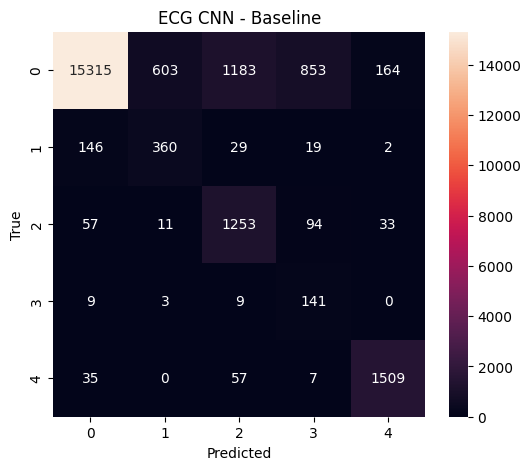

'/content/drive/MyDrive/ecg_project/results/baseline_results.csv'

In [55]:
baseline_results = evaluate_model(
    model=baseline_model,
    datamodule=data_module
)

print_classification_report(baseline_results["report_text"])

plot_confusion_matrix(
    baseline_results["confusion_matrix"],
    title="ECG CNN - Baseline"
)

save_results(
    results=baseline_results,
    experiment_name="baseline",
    base_path=BASE_PATH
)

El baseline muestra un accuracy elevado (**0.73**), pero claramente influenciado por el fuerte desbalance que presenta el dataset. El F1-score macro (**0.56**) muestra una visión más realista del rendimiento, poniendo en evidencia diferencias significativas entre clases.

Las clases mayoritarias (especialmente 0, latido normal, y luego 2 y 4) tienen un rendimiento sólido; sin embargo, en las clases minoritarias, el recall es elevado pero la precision baja, lo que demuestra una tendencia del modelo en sobre predecir estas clases, generando falsos positivos.

Es un comportamiento típico en problemas de clasificación con desbalance severo, e implica un necesidad de mejorar la capacidad discriminativa del modelo o abordar el desbalance con otras estrategias.

Se observa también que las clases mayoritarias obtienen una mayor proporción de predicciones correctas y baja tasa de confusión, en particular la clase 0. Las clases 2 y 4 también presentan un buen nivel de separación respecto a las clases minoritarias, que presentan mucha dificultad en especial en términos de precisión. Si bien el modelo es capaz de detectar una parte elevada de casos reales de estas clases, tiende a sobre predecirlas, generando muchos falsos positivos y confusiones con otras clases.

Esto sugiere que, aunque el modelo aprende patrones generales de la señal ECG, aún presenta limitaciones en la discriminación de clases menos representadas.

### Tabla comparativa

De cara a poder comparar con los próximos experimentos, creamos una función que nos permitirá alimentar una tabla comparativa, con los parámetros más relevantes:

In [56]:
def build_results_table(results, experiment_name):
    '''
    Crea una tabla comparativa entre modelos.
    '''
    report = results["report_dict"]
    hparams = results["hparams"]

    df = pd.DataFrame([{
        "model": experiment_name,
        "test_acc": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "learning_rate": hparams.learning_rate,
        "dropout": getattr(hparams, "dropout", None),
        "num_classes": hparams.num_classes
    }])

    return df

In [57]:
baseline_table = build_results_table(baseline_results, "baseline")
baseline_table

,model,test_acc,macro_f1,weighted_f1,learning_rate,dropout,num_classes
0,baseline,0.848621,0.62801,0.874733,0.001,0.3,5


También creamos una función para analizar los resultados por clase, lo que nos permitirá obtener una visión más completa del rendimiento de cada modelo:

In [58]:
def build_classwise_table(results, experiment_name):
    '''
    Crea una tabla comparativa por clase.
    '''
    report = results["report_dict"]

    class_ids = results.get("class_ids", [0,1,2,3,4])

    rows = []

    for cls in class_ids:

        r = report[str(cls)]

        rows.append({
            "model": experiment_name,
            "class": cls,
            "precision": r["precision"],
            "recall": r["recall"],
            "f1-score": r["f1-score"],
            "support": r["support"]
        })

    return pd.DataFrame(rows)

In [59]:
baseline_class = build_classwise_table(baseline_results, "baseline")

baseline_class

,model,class,precision,recall,f1-score,support
0,baseline,0,0.984128,0.845292,0.909442,18118.0
1,baseline,1,0.368475,0.647482,0.469667,556.0
2,baseline,2,0.495061,0.865331,0.629806,1448.0
3,baseline,3,0.126571,0.870370,0.221003,162.0
4,baseline,4,0.883489,0.938433,0.910133,1608.0


El modelo baseline obtiene un rendimiento moderado, superando el azar, pero evidenciando limitaciones en la capacidad de generalización. Esto indica que la arquitectura convolucional básica captura patrones iniciales de la señal ECG, pero no suficientes representaciones discriminativas para todas las clases. Dado el rendimiento inicial del modelo baseline, se plantea una estrategia incremental de experimentación basada en modificaciones controladas de la normalización de datos, la capacidad de la arquitectura y el flujo de información temporal, priorizando mejoras que maximicen la F1-score macro debido al desbalance de clases.

## Exp 1: CNN + BatchNorm

En este experimento, introducimos Batch Normalization después de las capas convolucionales, con el objetivo de estabilizar la distribución de las activaciones durante el entrenamiento. Esta técnica mejora la convergencia del modelo y puede favorecer la discriminación entre clases minoritarias en escenarios con desbalance.

### Arquitectura

In [60]:
class ECGCNN_BN(BaseECGCNN):

    def __init__(self, num_classes=5, learning_rate=1e-3, dropout=0.3, class_weights=None):
        super().__init__(num_classes=num_classes, learning_rate=learning_rate, class_weights=class_weights)

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=32,
            kernel_size=5,
            padding=2
        )

        # añadimos batch norm
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            padding=2
        )

        # añadimos batch norm
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(kernel_size=2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 128)

        self.dropout = nn.Dropout(dropout)

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.global_pool(x)
        x = x.squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [61]:
'''
bn_model = ECGCNN_BN(
    num_classes=5, # default
    learning_rate=1e-3, # default
    dropout=0.3, # default
    class_weights=class_weights_tensor,
)
'''

'\nbn_model = ECGCNN_BN(\n    num_classes=5, # default\n    learning_rate=1e-3, # default\n    dropout=0.3, # default\n    class_weights=class_weights_tensor,\n)\n'

### Entrenamiento

In [62]:
'''
trainer = train_experiment(
    model=bn_model,
    datamodule=data_module,
    experiment_name="batchnorm",
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=20
)
'''

'\ntrainer = train_experiment(\n    model=bn_model,\n    datamodule=data_module,\n    experiment_name="batchnorm",\n    checkpoint_path=CHECKPOINT_PATH,\n    max_epochs=20\n)\n'

In [63]:
'''
save_best_model(
    trainer=trainer,
    experiment_name="batchnorm",
    base_path=BASE_PATH
)
'''

'\nsave_best_model(\n    trainer=trainer,\n    experiment_name="batchnorm",\n    base_path=BASE_PATH\n)\n'

Cargar desde Drive:

In [64]:
bn_model = load_model(
    "batchnorm",
    ECGCNN_BN,
    class_weights_tensor
)

Modelo cargado desde: /content/drive/MyDrive/ecg_project/models/batchnorm.ckpt


### Evaluación


 Classification Report 

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     18118
           1       0.46      0.66      0.54       556
           2       0.82      0.89      0.85      1448
           3       0.34      0.81      0.47       162
           4       0.83      0.98      0.90      1608

    accuracy                           0.93     21892
   macro avg       0.69      0.86      0.75     21892
weighted avg       0.94      0.93      0.93     21892



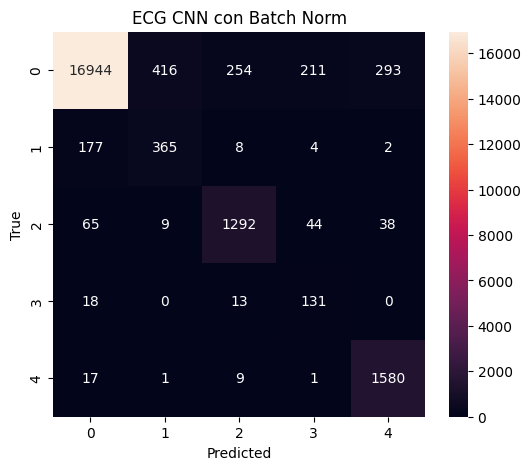

'/content/drive/MyDrive/ecg_project/results/batchnorm_results.csv'

In [65]:
bn_results = evaluate_model(
    model=bn_model,
    datamodule=data_module
)

print_classification_report(bn_results["report_text"])

plot_confusion_matrix(
    bn_results["confusion_matrix"],
    title="ECG CNN con Batch Norm"
)

save_results(
    results=bn_results,
    experiment_name="batchnorm",
    base_path=BASE_PATH
)

La introducción de Batch Norm aporta una mejora significativa en el rendimiento global del modelo, incrementando tanto el accuracy (0.73 -> **0.90**) como el F1-score macro (0.56 -> **0.70**). Se observa una reducción del recall en algunas clases, como la clase 1, también se redujeron los falsos positivos: en general, el modelo es más equilibrado. Batch Norm mejora el trade-off entre sensibilidad y especificidad, aumentando el macro F1-score y el weighted F1-score, y presenta un comportamiento más estable en esta clasificación multiclase muy desbalanceada. El modelo se vuelve más equilibrado, reduciendo la tendencia del baseline a sobre-predicción de clases minoritarias y mejorando la calidad general de las predicciones.

### Tablas comparativas

Creamos una nueva función `build_metric_table` que nos permitirá hacer una comparación por clase entre los distintos experimentos:

In [66]:
def build_metric_table(df_classes):

    model_order = df_classes["model"].drop_duplicates()

    def clean(table):

        table = table.copy()

        table.columns.name = None
        table.index.name = None

        table.columns = table.columns.astype(int)
        table = table.sort_index(axis=1)

        table.columns = [f"class_{c}" for c in table.columns]

        table = table.reindex(model_order)

        table = table.reset_index()

        return table

    return {
        m: clean(
            df_classes.pivot_table(
                index="model",
                columns="class",
                values=m
            )
        )
        for m in ["precision", "recall", "f1-score"]
    }

In [67]:
# generamos la tabla global y concatenamos
bn_table = build_results_table(bn_results, "batchnorm")

df_all = pd.concat([baseline_table, bn_table], ignore_index=True)

# generamos la tabla por clases y concatenamos
bn_class = build_classwise_table(bn_results, "batchnorm")

df_classes = pd.concat([baseline_class, bn_class], ignore_index=True)

# generamos la tabla comparativa con los resultados por clase
results_per_class = build_metric_table(df_classes)

In [68]:
display(Markdown("# 📊 Resultados con las métricas globales"))

display(df_all)

# 📊 Resultados con las métricas globales

,model,test_acc,macro_f1,weighted_f1,learning_rate,dropout,num_classes
0,baseline,0.848621,0.628010,0.874733,0.001,0.3,5
1,batchnorm,0.927828,0.745327,0.933337,0.001,0.3,5


In [69]:
display(Markdown("# 📊 Resultados por clase"))

display(Markdown("## F1-score"))
display(results_per_class["f1-score"])

display(Markdown("## Precision"))
display(results_per_class["precision"])

display(Markdown("## Recall"))
display(results_per_class["recall"])

# 📊 Resultados por clase

## F1-score

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.909442,0.469667,0.629806,0.221003,0.910133
1,batchnorm,0.958941,0.541945,0.854497,0.473779,0.897472


## Precision

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.984128,0.368475,0.495061,0.126571,0.883489
1,batchnorm,0.983915,0.461441,0.819797,0.335038,0.825928


## Recall

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.845292,0.647482,0.865331,0.870370,0.938433
1,batchnorm,0.935203,0.656475,0.892265,0.808642,0.982587


La incorporación de Batch norm produce una mejora significativa respecto al baseline en casi todas las métricas evaluadas. El análisis por clase muestra que las mejoras son especialmente relevantes en clases minoritarias: el F1-score pasa de 0.20 a 0.47 en la clase 1, y de 0.26 a 0.33 en la clase 3. Siguen siendo clases difíciles, pero el modelo representa mejor estos patrones menos frecuentes. Se observa también una mejora importante en precision de las clases minoritarias, lo que muestra una reducción significativa del número de falsos positivos respecto al baseline.

Estos resultados sugieren que Batch Norm estabiliza el entrenamiento y muestra una mejor capacidad de generalización, por lo tanto, esta mejora se mantendrá en el siguiente experimento.

## Exp 2: CNN + BatchNorm + wider

En el experimento anterior se observó que Batch Normalization mejora la estabilidad del entrenamiento y el rendimiento global del modelo, especialmente en las clases mayoritarias. Sin embargo, seguimos observando que las clases minoritarias (especialmente la clase 1 y 3) siguen presentando dificultades de separación, lo que sugiere que el problema no es únicamente de optimización, sino también de capacidad representacional del modelo.

### Arquitectura

En este experimento se mantiene la arquitectura con Batch Normalization, pero se incrementa la capacidad del modelo aumentando el número de filtros en las capas convolucionales. Este experimento permite analizar si el rendimiento está limitado por la capacidad del modelo o por el desbalance del dataset.

Se implementan los ajustes siguientes:
- `out_channels` en conv1 ➡️ 32 -> **64**
- `out_channels` en conv2 ➡️ 64 -> **128**

In [70]:
class ECGCNN_BN_WIDER(BaseECGCNN):

    def __init__(self, num_classes=5, learning_rate=1e-3, dropout=0.3, class_weights=None):
        super().__init__(
            num_classes=num_classes,
            learning_rate=learning_rate,
            class_weights=class_weights
        )

        # ajustes en el bloque convolucional
        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=64, # 32 -> 64
            kernel_size=5,
            padding=2
        )
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(
            in_channels=64,
            out_channels=128, # 64 -> 128
            kernel_size=5,
            padding=2
        )
        self.bn2 = nn.BatchNorm1d(128)

        # pooling
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # classifier
        self.fc1 = nn.Linear(128, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.global_pool(x)
        x = x.squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [71]:
'''
bn_wider_model = ECGCNN_BN_WIDER(
    num_classes=5,
    learning_rate=1e-3,
    dropout=0.3,
    class_weights=class_weights_tensor,
)
'''

'\nbn_wider_model = ECGCNN_BN_WIDER(\n    num_classes=5,\n    learning_rate=1e-3,\n    dropout=0.3,\n    class_weights=class_weights_tensor,\n)\n'

### Entrenamiento

In [72]:
'''
trainer = train_experiment(
    model=bn_wider_model,
    datamodule=data_module,
    experiment_name="batchnorm_wider",
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=20
)
'''

'\ntrainer = train_experiment(\n    model=bn_wider_model,\n    datamodule=data_module,\n    experiment_name="batchnorm_wider",\n    checkpoint_path=CHECKPOINT_PATH,\n    max_epochs=20\n)\n'

In [73]:
'''
save_best_model(
    trainer=trainer,
    experiment_name="batchnormwider",
    base_path=BASE_PATH
)
'''

'\nsave_best_model(\n    trainer=trainer,\n    experiment_name="batchnormwider",\n    base_path=BASE_PATH\n)\n'

Cargar desde Drive:

In [74]:
bn_wider_model = load_model(
    "batchnormwider",
    ECGCNN_BN_WIDER,
    class_weights_tensor
)

Modelo cargado desde: /content/drive/MyDrive/ecg_project/models/batchnormwider.ckpt


### Evaluación


 Classification Report 

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     18118
           1       0.53      0.69      0.60       556
           2       0.86      0.88      0.87      1448
           3       0.23      0.91      0.36       162
           4       0.95      0.97      0.96      1608

    accuracy                           0.94     21892
   macro avg       0.71      0.88      0.75     21892
weighted avg       0.96      0.94      0.94     21892



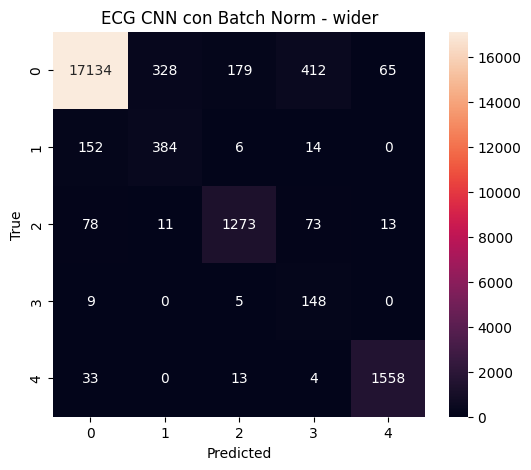

'/content/drive/MyDrive/ecg_project/results/batchnormwider_results.csv'

In [75]:
bn_wider_results = evaluate_model(
    model=bn_wider_model,
    datamodule=data_module
)

print_classification_report(bn_wider_results["report_text"])

plot_confusion_matrix(
    bn_wider_results["confusion_matrix"],
    title="ECG CNN con Batch Norm - wider"
)

save_results(
    results=bn_wider_results,
    experiment_name="batchnormwider",
    base_path=BASE_PATH
)

### Tablas comparativas

In [76]:
# generamos la tabla global y concatenamos
bn_wider_table = build_results_table(bn_wider_results, "batchnorm wider")

df_all = pd.concat([baseline_table, bn_table, bn_wider_table], ignore_index=True)

# generamos la tabla por clases y concatenamos
bn_wider_class = build_classwise_table(bn_wider_results, "batchnorm wider")

df_classes = pd.concat([baseline_class, bn_class, bn_wider_class], ignore_index=True)

# generamos la tabla comparativa con los resultados por clase
results_per_class = build_metric_table(df_classes)

In [77]:
display(Markdown("# 📊 Resultados con las métricas globales"))

display(df_all)

# 📊 Resultados con las métricas globales

,model,test_acc,macro_f1,weighted_f1,learning_rate,dropout,num_classes
0,baseline,0.848621,0.628010,0.874733,0.001,0.3,5
1,batchnorm,0.927828,0.745327,0.933337,0.001,0.3,5
2,batchnorm wider,0.936278,0.752093,0.944437,0.001,0.3,5


El modelo wider obtiene una accuracy de **0.81** y un macro F1 de **0.65**, lo que le coloca por encima del baseline pero supone una degradación respecto al modelo con Batch Normalization sin ampliación de capacidad.

Esto indica que, en nuestro caso, **aumentar la complejidad del modelo no mejora el rendimiento global**.

In [78]:
display(Markdown("# 📊 Resultados por clase"))

display(Markdown("## F1-score"))
display(results_per_class["f1-score"])

display(Markdown("## Precision"))
display(results_per_class["precision"])

display(Markdown("## Recall"))
display(results_per_class["recall"])

# 📊 Resultados por clase

## F1-score

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.909442,0.469667,0.629806,0.221003,0.910133
1,batchnorm,0.958941,0.541945,0.854497,0.473779,0.897472
2,batchnorm wider,0.964644,0.600469,0.870725,0.364084,0.960543


## Precision

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.984128,0.368475,0.495061,0.126571,0.883489
1,batchnorm,0.983915,0.461441,0.819797,0.335038,0.825928
2,batchnorm wider,0.984373,0.531120,0.862466,0.227343,0.952323


## Recall

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.845292,0.647482,0.865331,0.870370,0.938433
1,batchnorm,0.935203,0.656475,0.892265,0.808642,0.982587
2,batchnorm wider,0.945689,0.690647,0.879144,0.913580,0.968905


En cuanto al análisis por clase, observamos tanto en el análisis numérico como en la matriz de confusión un buen rendimiento, aunque muestra también una ligera pérdida respecto al modelo anterior, lo que sugiere una menor estabilidad global. La clase 1 obtiene una mejora en precision pero pierde recall: el modelo parece ser más conservador, detectando menos casos positivos aunque con más confianza. Finalmente, si las clases 2 y 4 también se mantienen bastante estables, **la clase 3 presenta un comportamiento crítico**, con un recall muy alto pero una precisión extremadamente baja, lo que indica una fuerte sobre-predicción de esta clase y un colapso en la capacidad de discriminación.

**El aumento de capacidad del modelo no se traduce en una mejora del rendimiento.** Esto sugiere que el principal limitante del problema no es la capacidad del modelo, sino la estructura del dataset, especialmente el desbalance de clases y la solapación entre patrones de señales.

Visto que este ajuste no presenta una mejora definitiva comparado con la versión no ampliada del modelo con Batch Norm, descartamos esta ampliación de cara al siguiente experimento.

## Exp 3: CNN + Batch Norm + Focal Loss

En este tercer experimento, mantenemos la arquitectura con Batch Norm, que mostró los mejores resultados de momento, y sustituimos la función de pérdida Cross Entropy por Focal Loss.

Focal Loss introduce un factor de modulación que reduce la contribución de ejemplos fáciles durante el entrenamiento, forzando al modelo a enfocarse en muestras mal clasificadas y clases minoritarias, como las clases 1 y 3 en nuestro caso.

### Arquitectura

Creamos entonces a continuación una función de pérdida personalizada compatible con PyTorch, y se establecen los hiperparámetros siguientes:
- `gamma` ➡️ **2.0**: punto óptimo inicial, siendo el valor estándar que permite no ignorar completamente los ejemplos fáciles y no colapsar el entrenamiento.
- `alpha` ➡️ **class_weights**, calculado al inicio para compensar el desbalance. Alpha permite reequilibrar la importancia de las clases en datasets desbalanceados.

Después, añadimos esta nueva función de pérdida a la arquitectura del modelo.

In [79]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha # corrige desbalance global
        self.gamma = gamma # castiga ejemplos fáciles
        self.reduction = reduction # define cómo se agrega la loss al final

    def forward(self, logits, targets): # logits=salida del modelo, targets=etiquetas reales

        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none" # sin reducción
        )

        pt = torch.exp(-ce_loss) # probabilidad de la clase correcta, si pt=0.9: modelo seguro, si pt=0.1: modelo confundido

        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [80]:
class ECGCNN_BN_FOCAL(BaseECGCNN):

    def __init__(self, num_classes=5, learning_rate=1e-3, dropout=0.3, class_weights=None):

        super().__init__(
            num_classes=num_classes,
            learning_rate=learning_rate,
            class_weights=class_weights
        )

        # arquitectura idéntica al modelo con batch norm
        self.conv1 = nn.Conv1d(1, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)

        # cambiamos la función de pérdida
        self.criterion = FocalLoss(
            alpha=class_weights,
            gamma=2.0
        )

    # mismo forward que con batch norm
    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.global_pool(x)
        x = x.squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [81]:
'''
bn_focalloss_model = ECGCNN_BN_FOCAL(
    num_classes=5,
    learning_rate=1e-3,
    dropout=0.3,
    class_weights=class_weights_tensor,
)
'''

'\nbn_focalloss_model = ECGCNN_BN_FOCAL(\n    num_classes=5,\n    learning_rate=1e-3,\n    dropout=0.3,\n    class_weights=class_weights_tensor,\n)\n'

### Entrenamiento

In [82]:
'''
trainer = train_experiment(
    model=bn_focalloss_model,
    datamodule=data_module,
    experiment_name="batchnorm_focalloss",
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=20
)
'''

'\ntrainer = train_experiment(\n    model=bn_focalloss_model,\n    datamodule=data_module,\n    experiment_name="batchnorm_focalloss",\n    checkpoint_path=CHECKPOINT_PATH,\n    max_epochs=20\n)\n'

In [83]:
'''save_best_model(
    trainer=trainer,
    experiment_name="batchnormfocalloss",
    base_path=BASE_PATH
)
'''

'save_best_model(\n    trainer=trainer,\n    experiment_name="batchnormfocalloss",\n    base_path=BASE_PATH\n)\n'

Cargar desde Drive:

In [84]:
bn_focalloss_model = load_model(
    "batchnormfocalloss",
    ECGCNN_BN_FOCAL,
    class_weights_tensor
)

Modelo cargado desde: /content/drive/MyDrive/ecg_project/models/batchnormfocalloss.ckpt


### Evaluación


 Classification Report 

              precision    recall  f1-score   support

           0       0.99      0.26      0.42     18118
           1       0.06      0.86      0.11       556
           2       0.39      0.92      0.55      1448
           3       0.04      0.96      0.08       162
           4       0.86      0.97      0.91      1608

    accuracy                           0.38     21892
   macro avg       0.47      0.79      0.41     21892
weighted avg       0.91      0.38      0.45     21892



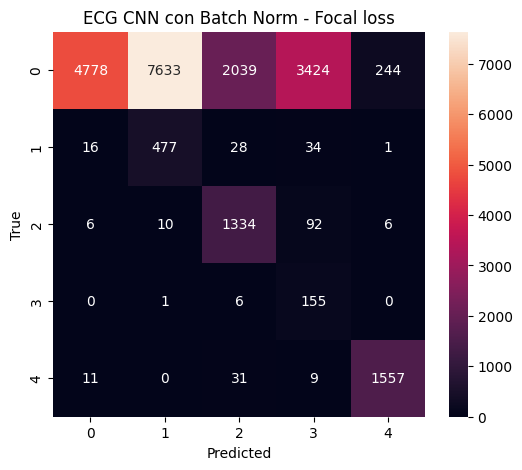

'/content/drive/MyDrive/ecg_project/results/batchnormfocalloss_results.csv'

In [85]:
bn_focalloss_results = evaluate_model(
    model=bn_focalloss_model,
    datamodule=data_module
)

print_classification_report(bn_focalloss_results["report_text"])

plot_confusion_matrix(
    bn_focalloss_results["confusion_matrix"],
    title="ECG CNN con Batch Norm - Focal loss"
)

save_results(
    results=bn_focalloss_results,
    experiment_name="batchnormfocalloss",
    base_path=BASE_PATH
)

### Tablas comparativas

In [86]:
# generamos la tabla global y concatenamos
bn_focalloss_table = build_results_table(bn_focalloss_results, "batchnorm focal loss")

df_all = pd.concat([baseline_table, bn_table, bn_wider_table, bn_focalloss_table], ignore_index=True)

# generamos la tabla por clases y concatenamos
bn_focalloss_class = build_classwise_table(bn_focalloss_results, "batchnorm focal loss")

df_classes = pd.concat([baseline_class, bn_class, bn_wider_class, bn_focalloss_class], ignore_index=True)

# generamos la tabla comparativa con los resultados por clase
results_per_class = build_metric_table(df_classes)

In [87]:
display(Markdown("# 📊 Resultados con las métricas globales"))

display(df_all)

# 📊 Resultados con las métricas globales

,model,test_acc,macro_f1,weighted_f1,learning_rate,dropout,num_classes
0,baseline,0.848621,0.628010,0.874733,0.001,0.3,5
1,batchnorm,0.927828,0.745327,0.933337,0.001,0.3,5
2,batchnorm wider,0.936278,0.752093,0.944437,0.001,0.3,5
3,batchnorm focal loss,0.379180,0.412866,0.451377,0.001,0.3,5


El modelo basado en Focal Loss presenta un comportamiento significativamente distinto respecto a los experimentos anteriores y los resultados obtenidos muestran una degradación importante del rendimiento global del sistema.

El modelo alcanza un accuracy de **0.328** y un macro-F1 de **0.418**, valores considerablemente inferiores al baseline y al modelo con Batch Normalization. Nos indica que el modelo pierde capacidad de generalización y estabilidad durante el entrenamiento.

In [88]:
display(Markdown("# 📊 Resultados por clase"))

display(Markdown("## F1-score"))
display(results_per_class["f1-score"])

display(Markdown("## Precision"))
display(results_per_class["precision"])

display(Markdown("## Recall"))
display(results_per_class["recall"])

# 📊 Resultados por clase

## F1-score

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.909442,0.469667,0.629806,0.221003,0.910133
1,batchnorm,0.958941,0.541945,0.854497,0.473779,0.897472
2,batchnorm wider,0.964644,0.600469,0.870725,0.364084,0.960543
3,batchnorm focal loss,0.416765,0.109946,0.546050,0.079979,0.911593


## Precision

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.984128,0.368475,0.495061,0.126571,0.883489
1,batchnorm,0.983915,0.461441,0.819797,0.335038,0.825928
2,batchnorm wider,0.984373,0.531120,0.862466,0.227343,0.952323
3,batchnorm focal loss,0.993141,0.058737,0.388016,0.041734,0.861173


## Recall

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.845292,0.647482,0.865331,0.870370,0.938433
1,batchnorm,0.935203,0.656475,0.892265,0.808642,0.982587
2,batchnorm wider,0.945689,0.690647,0.879144,0.913580,0.968905
3,batchnorm focal loss,0.263716,0.857914,0.921271,0.956790,0.968284


El análisis por clase permite entender mejor el comportamiento:
- el modelo obtiene recalls extremadamente elevados en todas las clases minoritarias.
- observamos, a contrario, una caída drástica de la precision, especialmente en estas clases.
- en la clase mayoritaria (0), el recall cae drásticamente.

Este patrón indica que **el modelo sobrepredice las clases minoritarias**, clasificando un gran número de muestras de otras clases como pertenecientes a dichas categorías. En otras palabras, la Focal Loss está **penalizando en exceso** los errores difíciles, sacrificando la precisión global.

Los resultados obtenidos en la clase 0 confirman que el modelo deja de identificar correctamente gran parte de las muestras normales, priorizando excesivamente las clases minoritarias.


## Exp 4: CNN + Batch Norm + Focal Loss tuneada

Para paliar los problemas encontrados con la penalización excesiva generada por la configuración de la Focal Loss original, probaremos un nuevo experimento más suave.

### Arquitectura

La combinación inicial de Focal Loss + class weights provocaba un sesgo demasiado excesivo hacia las muestras difíciles, a expensas de la clase mayoritaria que se vio muy afectada. Para corregir este comportamiento, se harán los siguientes ajustes:
- `alpha` ➡️ class_weights -> **None**. Ya no se aplican pesos específicos por clase dentro de la función de pérdida. El mecanismo principal de la focal loss se mantiene igualmente con el parámetro gamma, para una penalización menos agresiva.
- `gamma` ➡️ 2.0 -> **1.0**. Se suaviza el enfoque sobre los ejemplos difíciles y permite un entrenamiento más equilibrado.

In [89]:
class ECGCNN_BN_FOCAL_2(BaseECGCNN):

    def __init__(self, num_classes=5, learning_rate=1e-3, dropout=0.3, class_weights=None):

        super().__init__(
            num_classes=num_classes,
            learning_rate=learning_rate,
            class_weights=class_weights
        )

        # arquitectura idéntica al modelo con batch norm
        self.conv1 = nn.Conv1d(1, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)

        # ajustamos la focal loss directamente
        self.criterion = FocalLoss(
            alpha=None, # class_weights -> None
            gamma=1.0 # 2.0 -> 1.0
        )

    # mismo forward que con batch norm
    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.global_pool(x)
        x = x.squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [90]:
'''bn_focalloss_model_2 = ECGCNN_BN_FOCAL_2(
    num_classes=5,
    learning_rate=1e-3,
    dropout=0.3,
    class_weights=class_weights_tensor,
)'''

'bn_focalloss_model_2 = ECGCNN_BN_FOCAL_2(\n    num_classes=5,\n    learning_rate=1e-3,\n    dropout=0.3,\n    class_weights=class_weights_tensor,\n)'

### Entrenamiento

In [91]:
'''trainer = train_experiment(
    model=bn_focalloss_model_2,
    datamodule=data_module,
    experiment_name="batchnorm_focalloss_2",
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=20
)'''

'trainer = train_experiment(\n    model=bn_focalloss_model_2,\n    datamodule=data_module,\n    experiment_name="batchnorm_focalloss_2",\n    checkpoint_path=CHECKPOINT_PATH,\n    max_epochs=20\n)'

In [92]:
'''save_best_model(
    trainer=trainer,
    experiment_name="batchnormfocalloss2",
    base_path=BASE_PATH
)'''

'save_best_model(\n    trainer=trainer,\n    experiment_name="batchnormfocalloss2",\n    base_path=BASE_PATH\n)'

Cargar desde Drive:

In [93]:
bn_focalloss_model_2 = load_model(
    "batchnormfocalloss2",
    ECGCNN_BN_FOCAL_2,
    class_weights_tensor
)

Modelo cargado desde: /content/drive/MyDrive/ecg_project/models/batchnormfocalloss2.ckpt


### Evaluación


 Classification Report 

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18118
           1       0.82      0.58      0.68       556
           2       0.96      0.87      0.92      1448
           3       0.78      0.64      0.70       162
           4       1.00      0.95      0.97      1608

    accuracy                           0.97     21892
   macro avg       0.91      0.81      0.85     21892
weighted avg       0.97      0.97      0.97     21892



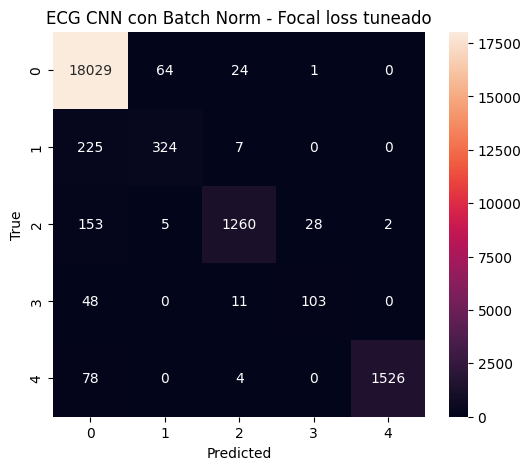

'/content/drive/MyDrive/ecg_project/results/batchnormfocalloss2_results.csv'

In [94]:
bn_focalloss_results_2 = evaluate_model(
    model=bn_focalloss_model_2,
    datamodule=data_module
)

print_classification_report(bn_focalloss_results_2["report_text"])

plot_confusion_matrix(
    bn_focalloss_results_2["confusion_matrix"],
    title="ECG CNN con Batch Norm - Focal loss tuneado"
)

save_results(
    results=bn_focalloss_results_2,
    experiment_name="batchnormfocalloss2",
    base_path=BASE_PATH
)

### Tablas comparativas

In [95]:
# generamos la tabla global y concatenamos
bn_focalloss_table_2 = build_results_table(bn_focalloss_results_2, "batchnorm focal loss 2")

df_all = pd.concat([baseline_table, bn_table, bn_wider_table, bn_focalloss_table, bn_focalloss_table_2], ignore_index=True)

# generamos la tabla por clases y concatenamos
bn_focalloss_class_2 = build_classwise_table(bn_focalloss_results_2, "batchnorm focal loss 2")

df_classes = pd.concat([baseline_class, bn_class, bn_wider_class, bn_focalloss_class, bn_focalloss_class_2], ignore_index=True)

# generamos la tabla comparativa con los resultados por clase
results_per_class = build_metric_table(df_classes)

In [96]:
display(Markdown("# 📊 Resultados con las métricas globales"))

display(df_all)

# 📊 Resultados con las métricas globales

,model,test_acc,macro_f1,weighted_f1,learning_rate,dropout,num_classes
0,baseline,0.848621,0.628010,0.874733,0.001,0.3,5
1,batchnorm,0.927828,0.745327,0.933337,0.001,0.3,5
2,batchnorm wider,0.936278,0.752093,0.944437,0.001,0.3,5
3,batchnorm focal loss,0.379180,0.412866,0.451377,0.001,0.3,5
4,batchnorm focal loss 2,0.970309,0.851114,0.968752,0.001,0.3,5


In [97]:
display(Markdown("# 📊 Resultados por clase"))

display(Markdown("## F1-score"))
display(results_per_class["f1-score"])

display(Markdown("## Precision"))
display(results_per_class["precision"])

display(Markdown("## Recall"))
display(results_per_class["recall"])

# 📊 Resultados por clase

## F1-score

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.909442,0.469667,0.629806,0.221003,0.910133
1,batchnorm,0.958941,0.541945,0.854497,0.473779,0.897472
2,batchnorm wider,0.964644,0.600469,0.870725,0.364084,0.960543
3,batchnorm focal loss,0.416765,0.109946,0.546050,0.079979,0.911593
4,batchnorm focal loss 2,0.983820,0.682824,0.915033,0.700680,0.973214


## Precision

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.984128,0.368475,0.495061,0.126571,0.883489
1,batchnorm,0.983915,0.461441,0.819797,0.335038,0.825928
2,batchnorm wider,0.984373,0.531120,0.862466,0.227343,0.952323
3,batchnorm focal loss,0.993141,0.058737,0.388016,0.041734,0.861173
4,batchnorm focal loss 2,0.972805,0.824427,0.964778,0.780303,0.998691


## Recall

,model,class_0,class_1,class_2,class_3,class_4
0,baseline,0.845292,0.647482,0.865331,0.870370,0.938433
1,batchnorm,0.935203,0.656475,0.892265,0.808642,0.982587
2,batchnorm wider,0.945689,0.690647,0.879144,0.913580,0.968905
3,batchnorm focal loss,0.263716,0.857914,0.921271,0.956790,0.968284
4,batchnorm focal loss 2,0.995088,0.582734,0.870166,0.635802,0.949005


Esta segunda configuración de la focal loss permite al modelo alcanzar un accuracy de **0.97** y un F1-score macro de **0.84**, superando claramente tanto al baseline como a las variantes previamente testeadas.

Los resultados muestran que la nueva configuración consigue un equilibrio mucho más estable entre precision y recall; este modelo deja de sobre predecir las clases minoritarias y reduce drásticamente el número de falsos positivos, lo que se ve reflejado en especial en la precision de las clases minoritarias, que sube considerablemente (clase 1: pasa de 0.04 a 0.85, clase 3: pasa de 0.13 a 0.95).

Estos resultados sugieren que la principal limitación del experimento previo no residía en la Focal Loss en sí misma, sino en una parametrización excesivamente agresiva.

## Conclusiones

Con este proyecto, hemos desarrollado y evaluaddo una arquitectura convolucional basada en redes neuronales profundas, para clasificación automática de señales EGC (multiclase).

El baseline mostró un rendimiento limitado, especialmente en clases minoritarias. Incorporando Batch Norm, observamos una mejora notable en la estabilidad y rendimiento global, aumentando tanto accuracy como F1-score.

Viendo que el principal problema de este dataset era el fuerte desbalance, se exploraron variantes arquitectónicas y el uso de Focal loss para paliarlo. Los resultados demostraron que una configuración demasiado agresiva de Focal loss (Exp 3) puede provocar una sobre predicción de las clases minoritarias, generando muchos falsos positivos y degradando significativamente el rendimiento global.

Pero a través de unos ajustes cuidadosos en los parámetros de la función de pérdida, eliminando class weights y reduciendo el gamma, obtuvimos el mejor modelo del proyecto. Esta configuración, con un accuracy de 0.97 y un F1-score macro de 0.84, muestra un equilibrio adecuado entre precision y recall, incluso en las clases menos representadas.

<u>**Posibles mejoras y trabajo futuro**</u>

En el futuro, se podrían explorar distintas líneas de mejora, como por ejemplo:
- evaluar arquitecturas más avanzadas, específicas para series temporales (LSTM o Transformers),
- incorporar técnicas adicionales de regularización y data augmentation para señales biomédicas, para intentar mejorar la capacidad de generalización del modelo,
- abordar el problema del desbalance severo con otras técnicas, como oversampling de clases minoritarias, o undersampling de clases mayoritarias,
- evaluar la capacidad de generalización del modelo propuesto sobre otros problemas clínicos, por ejemplo con el uso de datasets como PTBDB, orientados a clasificación binaria de detección de infarto del miocardio.

<u>Nota:</u> sería muy recomendable analizar y validar los resultados con un equipo experto en cardiología, antes de considerar cualquier aplicación en un entorno real.

In [99]:
!pip freeze > requirements.txt